In [7]:
pip install esda libpysal --break-system-packages

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached markupsafe-3.0.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (2.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 28.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 28.4 MB/s  0:00:00 eta 0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached markupsafe-3.0.3-cp313-cp313-macosx_11_0_arm64.whl (12 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [esda]2m 9/10 [esda]sal]arn]

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
import geopandas as gpd
import libpysal
from esda.getisord import G_Local
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# ---------- 第一步：读取MSOA边界，看一眼字段 ----------
msoa = gpd.read_file("/Users/wusiyi/Documents/CASA/DSSS/as/data/MSOA/MSOA_2011_London_gen_MHW.shp")
print(f"MSOA数量：{len(msoa)}")
print(f"字段：{msoa.columns.tolist()}")
print(f"CRS：{msoa.crs}")

/Users/wusiyi/Documents/CASA/dis/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MSOA数量：983
字段：['MSOA11CD', 'MSOA11NM', 'LAD11CD', 'LAD11NM', 'RGN11CD', 'RGN11NM', 'USUALRES', 'HHOLDRES', 'COMESTRES', 'POPDEN', 'HHOLDS', 'AVHHOLDSZ', 'geometry']
CRS：PROJCS["OSGB36 / British National Grid",GEOGCS["OSGB36",DATUM["Ordnance_Survey_of_Great_Britain_1936",SPHEROID["Airy 1830",6377563.396,299.3249646,AUTHORITY["EPSG","7001"]],AUTHORITY["EPSG","6277"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",49],PARAMETER["central_meridian",-2],PARAMETER["scale_factor",0.999601272],PARAMETER["false_easting",400000],PARAMETER["false_northing",-100000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


In [11]:
# ---------- 第二步：把事故点聚合到MSOA ----------
from shapely.geometry import Point

gdf_accidents = gpd.GeoDataFrame(
    df,
    geometry=[Point(xy) for xy in zip(df[lon_col], df[lat_col])],
    crs="EPSG:4326"
)
gdf_accidents = gdf_accidents.to_crs(msoa.crs)

joined = gpd.sjoin(gdf_accidents, msoa, how="inner", predicate="within")

msoa["area_km2"] = msoa.geometry.area / 1e6
counts = joined.groupby("index_right").size()
msoa["accident_count"] = msoa.index.map(counts).fillna(0)
msoa["accident_density"] = msoa["accident_count"] / msoa["area_km2"]

print(msoa[["accident_count", "accident_density"]].describe())

       accident_count  accident_density
count      983.000000        983.000000
mean       113.319430        115.165535
std         77.392009         98.168705
min          7.000000          3.652857
25%         65.000000         42.335537
50%         97.000000         82.754578
75%        139.000000        158.273963
max        938.000000        629.804402


In [12]:
# ---------- 第三步：用KNN空间权重做Getis-Ord Gi*（避开简化边界导致的孤岛问题） ----------
import libpysal
from esda.getisord import G_Local

w = libpysal.weights.KNN.from_dataframe(msoa, k=8)
w.transform = "r"

gi_star = G_Local(msoa["accident_density"].values, w, star=True, permutations=999)

msoa["gi_zscore"] = gi_star.Zs
msoa["gi_pvalue"] = gi_star.p_sim

print(msoa[["gi_zscore", "gi_pvalue"]].describe())

/Users/wusiyi/Documents/CASA/dis/venv/lib/python3.13/site-packages/esda/getisord.py:362: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  w, star = _infer_star_and_structure_w(w, star, transform)


        gi_zscore   gi_pvalue
count  983.000000  983.000000
mean     0.030148    0.103466
std      0.810184    0.135272
min     -1.032580    0.001000
25%     -0.610404    0.003000
50%     -0.241530    0.036000
75%      0.572457    0.163000
max      2.984132    0.500000


In [13]:
# ---------- 第四步：查Soho所在的MSOA ----------
from shapely.geometry import Point as ShapelyPoint

soho_point = gpd.GeoDataFrame(
    geometry=[ShapelyPoint(-0.1365, 51.5135)], crs="EPSG:4326"
).to_crs(msoa.crs)

soho_result = gpd.sjoin(soho_point, msoa, how="left", predicate="within")
print(soho_result[["MSOA11NM", "LAD11NM"]])

# 用查到的index_right从msoa里取出对应行的完整结果
soho_idx = soho_result["index_right"].iloc[0]
print(msoa.loc[soho_idx, ["MSOA11NM", "LAD11NM", "accident_count", "accident_density", "gi_zscore", "gi_pvalue"]])

          MSOA11NM      LAD11NM
0  Westminster 013  Westminster
MSOA11NM            Westminster 013
LAD11NM                 Westminster
accident_count                  649
accident_density         503.453547
gi_zscore                  2.317766
gi_pvalue                     0.001
Name: 939, dtype: object


In [14]:
print(f"全伦敦MSOA事故密度：均值{msoa['accident_density'].mean():.2f}, "
      f"中位数{msoa['accident_density'].median():.2f}, "
      f"Westminster 013排名第{(msoa['accident_density'] > 503.45).sum() + 1}/{len(msoa)}")

全伦敦MSOA事故密度：均值115.17, 中位数82.75, Westminster 013排名第5/983


图已保存：/Users/wusiyi/Documents/CASA/dis/DATA/sim_output/getis_ord_hotspot_london.png


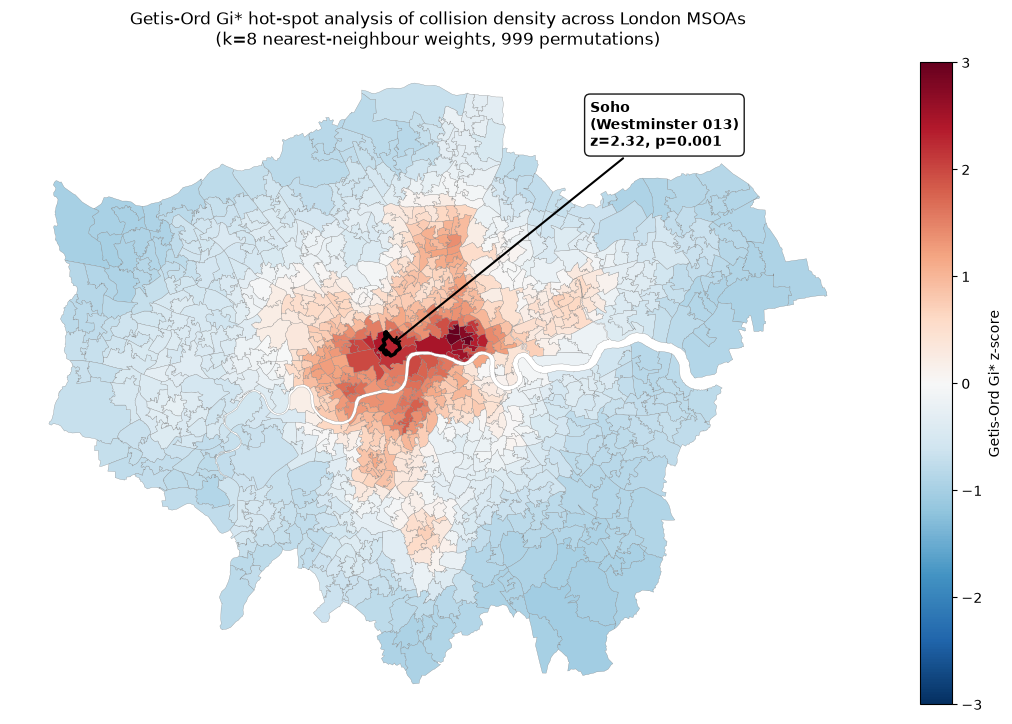

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(11, 11))

# 全伦敦983个MSOA，按Gi* z-score着色
msoa.plot(
    column="gi_zscore",
    cmap="RdBu_r",
    vmin=-3, vmax=3,          # 固定色阶范围，让±1.96(95%显著性)这个参照点在视觉上居中
    legend=True,
    ax=ax,
    edgecolor="grey",
    linewidth=0.2,
    legend_kwds={"label": "Getis-Ord Gi* z-score", "shrink": 0.6},
)

# 把Soho所在的MSOA单独描边高亮出来
soho_poly = msoa.loc[[soho_idx]]
soho_poly.boundary.plot(ax=ax, color="black", linewidth=2.5)

# 加一个指向Soho的标注
soho_centroid = soho_poly.geometry.centroid.iloc[0]
ax.annotate(
    "Soho\n(Westminster 013)\nz=2.32, p=0.001",
    xy=(soho_centroid.x, soho_centroid.y),
    xytext=(soho_centroid.x + 15000, soho_centroid.y + 15000),
    fontsize=10, fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="black", lw=1.5),
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", alpha=0.9),
)

ax.set_title("Getis-Ord Gi* hot-spot analysis of collision density across London MSOAs\n"
             "(k=8 nearest-neighbour weights, 999 permutations)", fontsize=12)
ax.set_axis_off()

plt.tight_layout()
out_path = "/Users/wusiyi/Documents/CASA/dis/DATA/sim_output/getis_ord_hotspot_london.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
print(f"图已保存：{out_path}")

In [16]:
top10 = msoa.sort_values("gi_zscore", ascending=False).head(10)
print(top10[["MSOA11NM", "LAD11NM", "accident_density", "gi_zscore", "gi_pvalue"]].to_string(index=False))

          MSOA11NM        LAD11NM  accident_density  gi_zscore  gi_pvalue
 Tower Hamlets 009  Tower Hamlets        307.425858   2.984132      0.001
 Tower Hamlets 015  Tower Hamlets        482.229761   2.965243      0.001
 Tower Hamlets 017  Tower Hamlets        629.804402   2.958390      0.001
 Tower Hamlets 013  Tower Hamlets        399.161579   2.719048      0.001
 Tower Hamlets 021  Tower Hamlets        460.437639   2.633624      0.001
 Tower Hamlets 026  Tower Hamlets        259.252886   2.551568      0.001
 Tower Hamlets 022  Tower Hamlets        340.387242   2.541660      0.001
City of London 001 City of London        266.056372   2.472714      0.001
   Westminster 011    Westminster        382.296271   2.434492      0.001
 Tower Hamlets 016  Tower Hamlets        352.553114   2.355233      0.001


In [17]:
import sys
sys.path.insert(0, "/Users/wusiyi/Documents/CASA/dis/DATA/files")
from environment import load_environment

env = load_environment("/Users/wusiyi/Documents/CASA/dis/DATA")
ranked = sorted(env.poi_nodes, key=lambda item: item[1], reverse=True)
gap = [node for node, _w in ranked if not env.has_nearby_cycle_parking(node)]
print(f"当前缺口节点数：{len(gap)}")

  [env] 路网已投影：EPSG:32630
  [env] 路网节点 5313，路段 11210
  [env] 路段宽度：224 条来自 OSM width 标签，其余用类型默认值
  [env] POI 5202 个吸附到 1695 个节点
  [env] land_use_mix：均值 0.03，最大 1.00
  [env] activity landuse：604 个地块（类别：['commercial', 'education', 'governmental', 'religious', 'residential', 'retail']）
  [env] activity_density：均值 0.05，最大 1.00
  [env] 装卸区 39 个吸附到 24 个节点
  [env] 自行车停放 1523 个吸附到 915 个节点
  [env] 边界已加载并投影到 EPSG:32630
当前缺口节点数：607


In [18]:
import pandas as pd
df = pd.read_csv("/Users/wusiyi/Documents/CASA/dis/DATA/sim_output/conflicts_S2_adverse_seed1_riders300_peds600_hub5_share1_lut0.2.csv")
print(df["route_trigger"].value_counts(normalize=True))

route_trigger
land_use      0.418894
stress        0.364734
congestion    0.216372
Name: proportion, dtype: float64


In [19]:
import sys
sys.path.insert(0, "/Users/wusiyi/Documents/CASA/dis/DATA/files")
from environment import load_environment
from interventions import select_micro_hubs

env = load_environment("/Users/wusiyi/Documents/CASA/dis/DATA")
hubs = select_micro_hubs(env, n=5)
for node in hubs:
    print(node, "已有覆盖:", env.has_nearby_cycle_parking(node),
          "连续覆盖度:", round(env.legal_parking_coverage(node), 3))

  [env] 路网已投影：EPSG:32630
  [env] 路网节点 5313，路段 11210
  [env] 路段宽度：224 条来自 OSM width 标签，其余用类型默认值
  [env] POI 5202 个吸附到 1695 个节点
  [env] land_use_mix：均值 0.03，最大 1.00
  [env] activity landuse：604 个地块（类别：['commercial', 'education', 'governmental', 'religious', 'residential', 'retail']）
  [env] activity_density：均值 0.05，最大 1.00
  [env] 装卸区 39 个吸附到 24 个节点
  [env] 自行车停放 1523 个吸附到 915 个节点
  [env] 边界已加载并投影到 EPSG:32630
9791495 已有覆盖: True 连续覆盖度: 1.0
1614926348 已有覆盖: True 连续覆盖度: 0.593
107860 已有覆盖: True 连续覆盖度: 1.0
2191480791 已有覆盖: False 连续覆盖度: 0.426
3091103167 已有覆盖: True 连续覆盖度: 0.804
